<a href="https://colab.research.google.com/github/Adi1011-Data/Credit-Card-Fraud-Detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [33]:
X = df.drop('Class',axis=1)
y = df['Class']

In [4]:
X.shape

(97142, 30)

In [5]:
y.shape

(97142,)

In [6]:
df['Amount']

,Amount
0,149.62
1,2.69
2,378.66
3,123.50
4,69.99
...,...
97137,89.00
97138,3.60
97139,1.00
97140,1.00


In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [19]:
df[df.isnull().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
97141,66087,0.310485,-2.576074,1.002015,0.011196,-2.280745,0.465648,-0.860224,0.156411,0.087629,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df = df.dropna()

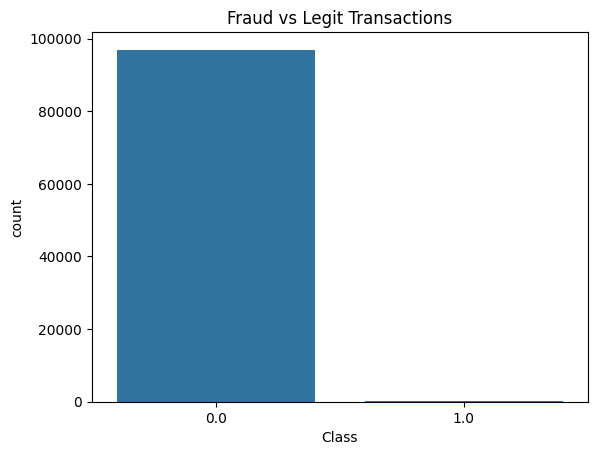

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Class", data=df)
plt.title("Fraud vs Legit Transactions")
plt.show()

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [35]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print("Class Weight:", scale_pos_weight)

Class Weight: 435.5842696629214


In [36]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight*0.5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [37]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.7).astype(int)

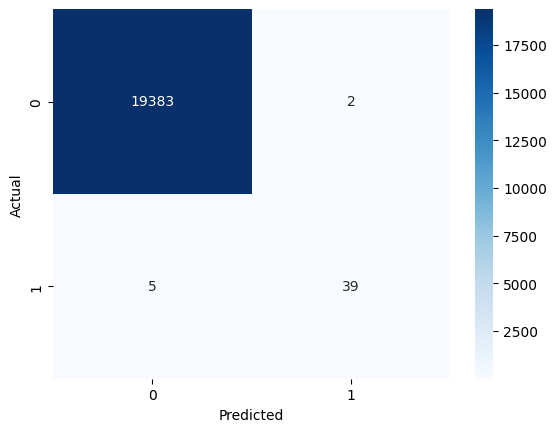

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     19385
         1.0       0.95      0.89      0.92        44

    accuracy                           1.00     19429
   macro avg       0.98      0.94      0.96     19429
weighted avg       1.00      1.00      1.00     19429



In [40]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.9771765892090885


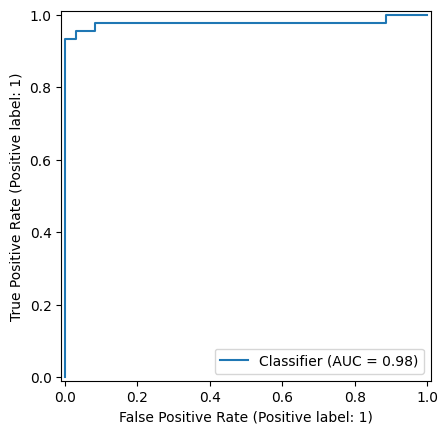

In [41]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.show()

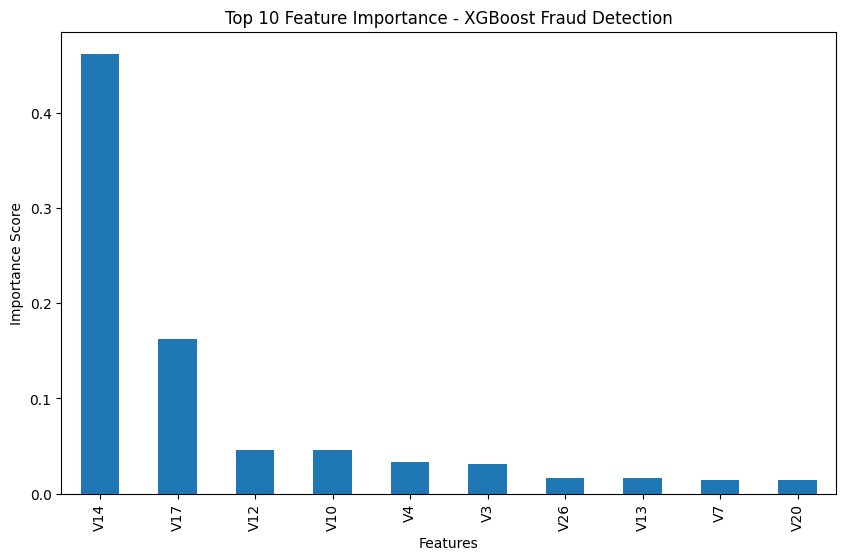

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

importance = model.feature_importances_

features = pd.Series(importance, index=X.columns)

top_features = features.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_features.plot(kind="bar")

plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Top 10 Feature Importance - XGBoost Fraud Detection")

plt.show()

In [46]:
import joblib

joblib.dump(model,"fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [48]:
!pip freeze > requirements.txt